# LIME plausibility

In this notebook we look deeper into the *plausibility* results of <br>
the study **Heyen et al. (2024)** – *“The Effect of Model Size on LLM Post-hoc Explainability via LIME”*. <br>
Plasibility was meassured as the IoU between LIME explanations and human rationales <br>
on the e-SNLI dataset (Camburu et al., 2018) and the CoS-e (Rajani et al., 2019) dataset.

We will:
- Read the **plausibility (IoU)** numbers from the authors repo.
- Compare plausibility against **accuracy** for both datasets.
- Inspect how plausibility is computed and interpreted in the paper and in the released code.
- And inspect the default **LIME hyperparameters** used in repo.

In [6]:
# Please install these dependancies in your virtual env first:
"""
# Install notebooks requirements
pip install -q pandas matplotlib
pip install seaborn
"""

import sys
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Clone authors repo
REPO_URL = "https://github.com/henningheyen/Scalability-Of-LLM-Posthoc-Explanations.git"
REPO_DIR = Path("Scalability-Of-LLM-Posthoc-Explanations")

if not REPO_DIR.exists():
    !git clone {REPO_URL}
    !pip install -q -r {REPO_DIR / "requirements.txt"}

In [7]:
# Paths
BASE_DIR = Path(".")
REPO_DIR = BASE_DIR / "Scalability-Of-LLM-Posthoc-Explanations"
DATA_DIR = REPO_DIR / "data"
RESULTS_DIR = REPO_DIR / "results"
TABLES_DIR = RESULTS_DIR / "tables"
JSON_DIR = RESULTS_DIR / "json"

# Defaults for plots
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True
sns.set_theme(style="whitegrid")

In [8]:
# Repo structure
for p in [REPO_DIR, DATA_DIR, RESULTS_DIR, TABLES_DIR, JSON_DIR]:
    print(f"{p}: {'OK' if p.exists() else 'MISSING'}")

print("\nTables:")
for f in sorted(TABLES_DIR.glob("*.csv")):
    print("  -", f.name)

print("\nJSON:")
for f in sorted(JSON_DIR.glob("*.json")):
    print("  -", f.name)

print("\nRaw e-SNLI:")
for f in sorted(DATA_DIR.glob("*.csv")):
    print("  -", f.name)

Scalability-Of-LLM-Posthoc-Explanations: OK
Scalability-Of-LLM-Posthoc-Explanations\data: OK
Scalability-Of-LLM-Posthoc-Explanations\results: OK
Scalability-Of-LLM-Posthoc-Explanations\results\tables: OK
Scalability-Of-LLM-Posthoc-Explanations\results\json: OK

Tables:
  - df_accurary.csv
  - df_all_metrics.csv
  - df_count_by_label.csv
  - df_count_by_prediction.csv
  - df_explainability_results.csv
  - df_faithfulness_by_prediction.csv
  - df_faithfulness_nli_by_label.csv
  - df_plausibility_by_label.csv
  - df_plausibility_by_prediction.csv

JSON:
  - confidence_intervals.json
  - explainability_results_cose_large.json
  - explainability_results_cose_wo_large.json
  - explainability_results_esnli.json
  - explainability_results_mnli.json
  - predictions_for_explanations.json
  - results.json

Raw e-SNLI:
  - esnli_dev.csv


## Plausibility (IoU) in the context of Heyen et al.

Plausibility is measured as <br>
$
\operatorname{IoU}(x_1, x_2) = \frac{|x_1 \cap x_2|}{|x_1 \cup x_2|}
$

for:
> “the number of most important tokens according to the average explanation length provided by humans”.

Explanations are:
> “always calculated with respect to the **predicted** class, not necessarily the correct class”.

This is interpreted as:
> “agreement between extracted and human rationale” (based on DeYoung et al., 2020).

### The Issue: 

On **misclassified** examples, the authors measure the <br>
IoU between an explanation **for a wrong decision** and the **human rationale for the right answer**.

Furthermore for **CoS-E**, accuracy is reported at only **0.33–0.38**. <br>
A big fraction is misclassified and the paper still aggregates one plausibility score and states:
> “agreement with human annotations does not increase [with model size]”
and they conclude a
> “misalignment between the LIME explanations and the models’ internal processes as model size increases”.


We conclude: the IoU with human highlights in this setup does **not necessarily reflect** any “true” internal reasoning:
- Human annotations might be noisy or the classifier just performes unreliably/unstable on perturbed inputs (especially on CoS-E).
- LIME hyperparameters might be suboptimal (num_samples, kernel, width, distance metric, token/feature granularity).

The next cells compute new plots for the IoU values separate for correct and incorrect predictions.<br>
For this we need to merge the data into a new table.

In [19]:
# Load Metrics table 
df_all = pd.read_csv(TABLES_DIR / "df_all_metrics.csv")
print("df_all shape:", df_all.shape)
print("Available metrics:", df_all["Metric"].unique())
#print(df_all.head(10).to_string(index=False))

df_all shape: (36, 5)
Available metrics: ['accuracy' 'percision' 'recall' 'f1']


In [20]:
# Load Accuracy
df_acc = (
    df_all[df_all["Metric"].str.lower() == "accuracy"]
    .sort_values(["Dataset", "Model_Size"])
    .reset_index(drop=True))
print("Accuracy rows:", df_acc.shape)
#print(df_acc.to_string(index=False))


# Normalizations for consistent naming
# 
# In the repo df_all uses cose, esnli, mnli
# df_pl_label uses e-SNLI
# df_pl_pred uses ESNLI, COSE
#
# We will put it all to lowercase without special chars
def normalize_dataset_name(s: str):
    s = s.strip().lower()
    mapping = {
        "e-snli": "esnli",
        "esnli": "esnli",
        "cose": "cose",
        "mnli": "mnli"}
    return mapping.get(s, s)

def normalize_model_size(s: str):
    return s.strip().lower()

df_acc["Dataset_norm"] = df_acc["Dataset"].map(normalize_dataset_name)
df_acc["Model_Size_norm"] = df_acc["Model_Size"].map(normalize_model_size)

# Filter relevant columns
df_acc = df_acc[["Dataset_norm", "Model_Size_norm", "Value", "95% C.I."]].rename(
    columns={"Value": "accuracy", "95% C.I.": "accuracy_CI"}
)
print(df_acc)

Accuracy rows: (12, 5)
   Dataset_norm Model_Size_norm  accuracy         accuracy_CI
0          cose            base   0.35872  (0.33251, 0.38329)
1          cose           large   0.37756  (0.35053, 0.40541)
2          cose           small   0.33579    (0.30876, 0.362)
3          cose          xsmall   0.33088   (0.30467, 0.3579)
4         esnli            base   0.93142   (0.92654, 0.9366)
5         esnli           large   0.93213  (0.92725, 0.93721)
6         esnli           small   0.92197  (0.91688, 0.92735)
7         esnli          xsmall   0.92034  (0.91485, 0.92562)
8          mnli            base   0.89995  (0.89404, 0.90565)
9          mnli           large   0.90199  (0.89628, 0.90769)
10         mnli           small   0.87794  (0.87121, 0.88406)
11         mnli          xsmall   0.87835  (0.87162, 0.88467)


In [21]:
# Load plausibility tables and normalize names
df_pl_label = pd.read_csv(TABLES_DIR / "df_plausibility_by_label.csv")
df_pl_pred  = pd.read_csv(TABLES_DIR / "df_plausibility_by_prediction.csv")
print("plausibility_by_label columns:", list(df_pl_label.columns))
print("plausibility_by_prediction columns:", list(df_pl_pred.columns))

# normalize names
df_pl_label["Dataset_norm"] = df_pl_label["Dataset"].apply(normalize_dataset_name)
df_pl_label["Model_Size_norm"] = df_pl_label["Model Size" ].apply(normalize_model_size)
df_pl_pred["Dataset_norm"] = df_pl_pred["Dataset"].apply(normalize_dataset_name)
df_pl_pred["Model_Size_norm"] = df_pl_pred["Model_Size"].apply(normalize_model_size)

# The IoU column contains strings like "0.290 (+- 0.017)"
# We split it into value and std
def split_iou_column(df, src_col="IoU"):
    m = df[src_col].str.extract(r"\s*([0-9.]+)\s*\(\s*\+\-\s*([0-9.]+)\s*\)\s*")
    df[src_col + "_val"] = m[0].astype(float)
    df[src_col + "_std"] = m[1].astype(float)
split_iou_column(df_pl_label, "IoU")
split_iou_column(df_pl_pred, "IoU")

# Filter
df_pl_label = df_pl_label[["Dataset_norm", "Model_Size_norm", "IoU_val", "IoU_std", "Label"]]
df_pl_pred = df_pl_pred[["Dataset_norm", "Model_Size_norm", "IoU_val", "Prediction_Status"]]
# print("\nIoU by label (head):\n", df_pl_label)
# print("\nIoU by prediction (head):\n", df_pl_pred)

plausibility_by_label columns: ['Dataset', 'Model Size', 'Label', 'IoU']
plausibility_by_prediction columns: ['Dataset', 'Model_Size', 'Prediction_Status', 'IoU']


In [22]:
# Filter CoS-E and e-SNLI only
df_pred_iou = df_pl_pred[df_pl_pred["Dataset_norm"].isin(["esnli", "cose"])].copy()

# merge accuracy and IoU-by-prediction
df_merged = df_pred_iou.merge(
    df_acc,
    on=["Dataset_norm", "Model_Size_norm"],
    how="left")
df_merged.head(12)

,Dataset_norm,Model_Size_norm,IoU_val,Prediction_Status,accuracy,accuracy_CI
0,esnli,xsmall,0.290,Correct,0.92034,"(0.91485, 0.92562)"
1,esnli,xsmall,0.183,Incorrect,0.92034,"(0.91485, 0.92562)"
2,esnli,small,0.268,Correct,0.92197,"(0.91688, 0.92735)"
3,esnli,small,0.156,Incorrect,0.92197,"(0.91688, 0.92735)"
4,esnli,base,0.262,Correct,0.93142,"(0.92654, 0.9366)"
5,esnli,base,0.100,Incorrect,0.93142,"(0.92654, 0.9366)"
6,esnli,large,0.254,Correct,0.93213,"(0.92725, 0.93721)"
7,esnli,large,0.280,Incorrect,0.93213,"(0.92725, 0.93721)"
8,cose,xsmall,0.217,Correct,0.33088,"(0.30467, 0.3579)"
9,cose,xsmall,0.243,Incorrect,0.33088,"(0.30467, 0.3579)"


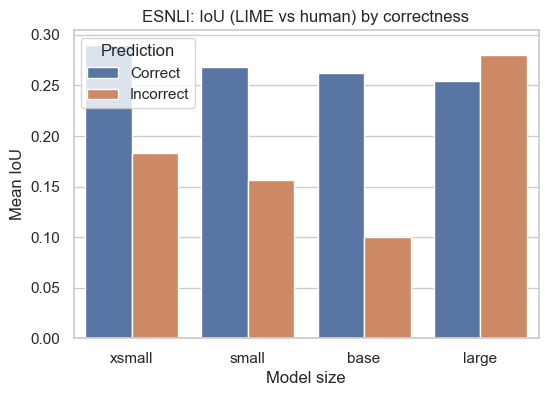

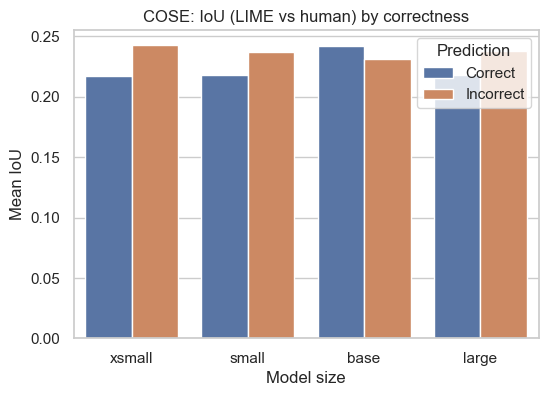

In [23]:
# IoU split by correctness per dataset 
for ds in ["esnli", "cose"]:
    sub = df_merged[df_merged["Dataset_norm"] == ds]
    if sub.empty:
        continue

    fig, ax = plt.subplots()
    sns.barplot(
        data=sub,
        x="Model_Size_norm",
        y="IoU_val",
        hue="Prediction_Status",
        ax=ax,
    )
    ax.set_title(f"{ds.upper()}: IoU (LIME vs human) by correctness")
    ax.set_xlabel("Model size")
    ax.set_ylabel("Mean IoU")
    ax.legend(title="Prediction")
    plt.show()

Discussion:

<div style="border:1px solid; padding:10px">
On e-SNLI the classifier is very accurate (~0.92–0.93).<br> For xs,s,b models, 
LIME explanations of correct predictions have higher IoU with human
highlights than explanations of incorrect ones. <br>
On this dataset plausibility partly aligns with correctness. <br><br>

However, for the large model incorrect predictions now
have higher IoU than correct predictions.  <br>
This might be a failure mode of the LIME method on larger models,  <br>
or the model might really perform more human-like
w.r.t. incorrect decisions under the IoU metric. <br>
</div>

<div style="border:1px solid; padding:10px">
On CoS-E the authors evaluated for 100 test samples over 3 clases. <br>
The classifier had an accuracy of 0.33–0.38. <br><br>
Explanations for correct predictions appear just as plausible <br>
as explanations for Incorrect ones by IoU (slightly higher for xs, s and l). <br>
Plausibility (IoU) does not distinguish correct from wrong decisions on CoS-E.
</div>

To ensure correctness of the results, here we reproduce the original plot from the paper:

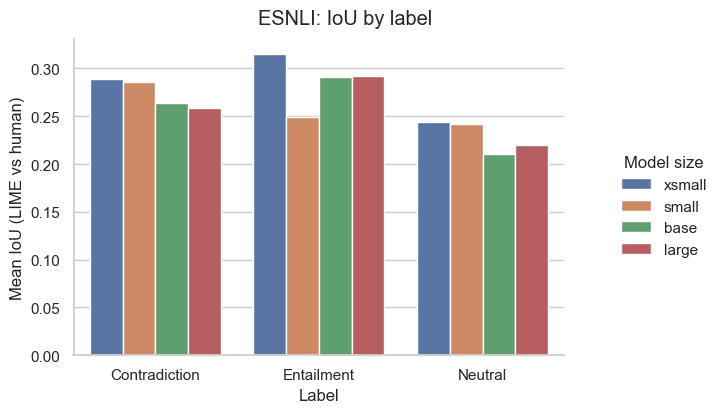

In [25]:
# For comparison we reproduce the original visualization by label:
for ds in ["esnli", "cose"]:
    sub_plot = df_pl_label[df_pl_label["Dataset_norm"] == ds]
    if sub_plot.empty:
        continue

    g = sns.catplot(
        data=sub_plot,
        x="Label",
        y="IoU_val",
        hue="Model_Size_norm",
        kind="bar",
        height=4,
        aspect=1.5,
    )
    g.set_axis_labels("Label", "Mean IoU (LIME vs human)")
    g._legend.set_title("Model size")
    g.figure.suptitle(f"{ds.upper()}: IoU by label", y=1.03)
    plt.show()

Here you see the LIME defaults from the authors repository:

In [26]:
# LIME defaults from Explainer
# (The authors did not mention the settings they used)
REPO_DIR = Path("Scalability-Of-LLM-Posthoc-Explanations")
sys.path.append(str(REPO_DIR))  # add repo to import path
from explainer import Explainer
import inspect

exp = Explainer()
sig = inspect.signature(exp.compute_explanations)

defaults = {
    "random_state": exp.random_state,
    "kernel_width": exp.kernel_width,
    "num_samples": sig.parameters["num_samples"].default,
    "num_features": sig.parameters["num_features"].default}  # None means all tokens used
print(defaults)

{'random_state': 42, 'kernel_width': 25, 'num_samples': 100, 'num_features': None}
